# Topology Optimization for 2D Steady-State Heat Transfer

## Governing PDE and Discretization

We study steady-state conduction on the unit square $\Omega = [0,1]^2$. Each square element carries a relative density $x_i \in [0,1]$ which modulates the local conductivity via a SIMP-style power law,
$$k(x_i) = k_{\min} + x_i^p (k_{\max} - k_{\min}).$$ 

The temperature field $u$ satisfies
$$-\nabla \cdot (k(x) \nabla u) = 0 \quad \text{in } \Omega,$$

with Dirichlet data $u= T_{\text{hot}}$ along the bottom boundary and $u = T_{\text{cold}}$ along the top edge. Left and right boundaries enforce an adiabatic condition. We discretize $u$ on an $n_x \times n_y$ grid of cell centers and assemble a five-point finite-volume operator whose edge conductivities are the arithmetic mean of adjacent cell conductivities. Solving the linear system yields the state $u(x)$.

In [28]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt
from matplotlib import animation
from dataclasses import dataclass
from IPython.display import HTML, display

np.set_printoptions(precision=3, suppress=True)
plt.rcParams.update({
    "image.cmap": "inferno",
    "figure.figsize": (6, 4),
    "axes.grid": False
})

In [29]:
@dataclass
class TopologyHeatProblem:
    """Finite-volume model of density-dependent conduction."""

    nx: int
    ny: int
    k_min: float = 1e-3
    k_max: float = 1.0
    penalty: float = 3.0
    T_hot: float = 1.0
    T_cold: float = 0.0

    def __post_init__(self) -> None:
        self.num_nodes = self.nx * self.ny
        self.hx = 1.0 / (self.nx - 1)
        self.hy = 1.0 / (self.ny - 1)
        self.inv_hx2 = 1.0 / (self.hx ** 2)
        self.inv_hy2 = 1.0 / (self.hy ** 2)

    def reshape_density(self, density: np.ndarray) -> np.ndarray:
        arr = np.asarray(density, dtype=float).reshape(self.ny, self.nx)
        return arr

    def _idx(self, i: int, j: int) -> int:
        return j * self.nx + i

    def _material_interpolation(self, density: np.ndarray) -> np.ndarray:
        return self.k_min + np.power(np.clip(density, 0.0, 1.0), self.penalty) * (self.k_max - self.k_min)

    def _material_sensitivity(self, density: np.ndarray) -> np.ndarray:
        safe = np.clip(density, 1e-6, 1.0)
        return self.penalty * (self.k_max - self.k_min) * np.power(safe, self.penalty - 1.0)

    def assemble_system(self, density: np.ndarray) -> tuple:
        dens = self.reshape_density(density)
        conductivity = self._material_interpolation(dens)
        rows, cols, data = [], [], []
        rhs = np.zeros(self.num_nodes)

        for j in range(self.ny):
            for i in range(self.nx):
                p = self._idx(i, j)
                if j == 0:
                    rows.append(p)
                    cols.append(p)
                    data.append(1.0)
                    rhs[p] = self.T_hot
                    continue
                if j == self.ny - 1:
                    rows.append(p)
                    cols.append(p)
                    data.append(1.0)
                    rhs[p] = self.T_cold
                    continue

                diag = 0.0
                if i > 0:
                    k_face = 0.5 * (conductivity[j, i] + conductivity[j, i - 1])
                    coeff = k_face * self.inv_hx2
                    rows.append(p)
                    cols.append(self._idx(i - 1, j))
                    data.append(-coeff)
                    diag += coeff
                if i + 1 < self.nx:
                    k_face = 0.5 * (conductivity[j, i] + conductivity[j, i + 1])
                    coeff = k_face * self.inv_hx2
                    rows.append(p)
                    cols.append(self._idx(i + 1, j))
                    data.append(-coeff)
                    diag += coeff
                if j > 0:
                    k_face = 0.5 * (conductivity[j, i] + conductivity[j - 1, i])
                    coeff = k_face * self.inv_hy2
                    rows.append(p)
                    cols.append(self._idx(i, j - 1))
                    data.append(-coeff)
                    diag += coeff
                if j + 1 < self.ny:
                    k_face = 0.5 * (conductivity[j, i] + conductivity[j + 1, i])
                    coeff = k_face * self.inv_hy2
                    rows.append(p)
                    cols.append(self._idx(i, j + 1))
                    data.append(-coeff)
                    diag += coeff

                rows.append(p)
                cols.append(p)
                data.append(diag)

        matrix = sp.coo_matrix((data, (rows, cols)), shape=(self.num_nodes, self.num_nodes)).tocsr()
        return matrix, rhs

    def solve_temperature(self, density: np.ndarray) -> np.ndarray:
        matrix, rhs = self.assemble_system(density)
        solution = spla.spsolve(matrix, rhs)
        return solution.reshape(self.ny, self.nx)

    def thermal_compliance(self, density: np.ndarray, state: np.ndarray) -> float:
        dens = self.reshape_density(density)
        u = np.asarray(state, dtype=float).reshape(self.ny, self.nx)
        conductivity = self._material_interpolation(dens)
        energy = 0.0
        for j in range(self.ny):
            for i in range(self.nx):
                if i + 1 < self.nx:
                    k_face = 0.5 * (conductivity[j, i] + conductivity[j, i + 1])
                    grad = (u[j, i + 1] - u[j, i]) / self.hx
                    energy += k_face * grad * grad
                if j + 1 < self.ny:
                    k_face = 0.5 * (conductivity[j, i] + conductivity[j + 1, i])
                    grad = (u[j + 1, i] - u[j, i]) / self.hy
                    energy += k_face * grad * grad
        return float(energy * self.hx * self.hy)

    def compliance_gradient(self, density: np.ndarray, state: np.ndarray) -> np.ndarray:
        dens = self.reshape_density(density)
        u = np.asarray(state, dtype=float).reshape(self.ny, self.nx)
        dconductivity = self._material_sensitivity(dens)
        grad = np.zeros_like(dens)
        area = self.hx * self.hy

        for j in range(self.ny):
            for i in range(self.nx):
                if i + 1 < self.nx:
                    diff = (u[j, i + 1] - u[j, i]) / self.hx
                    contrib = diff * diff * area * 0.5
                    grad[j, i] += dconductivity[j, i] * contrib
                    grad[j, i + 1] += dconductivity[j, i + 1] * contrib
                if j + 1 < self.ny:
                    diff = (u[j + 1, i] - u[j, i]) / self.hy
                    contrib = diff * diff * area * 0.5
                    grad[j, i] += dconductivity[j, i] * contrib
                    grad[j + 1, i] += dconductivity[j + 1, i] * contrib
        return grad

## Optimization Model and Sensitivities

For a design field $x = \{x_i\}_{i=1}^n$ we solve $A(x) u = b$ and evaluate the thermal compliance

$$J(x) = \int_\Omega k(x) \, \| \nabla u(x)\|^2 \, d\Omega \approx h_x h_y \sum_{i,j} \Big[\bar{k}_{i+1/2,j} \big(\frac{u_{i+1,j}-u_{i,j}}{h_x}\big)^2 + \bar{k}_{i,j+1/2} \big(\frac{u_{i,j+1}-u_{i,j}}{h_y}\big)^2 \Big],$$

where the face conductivities $\bar{k}$ are arithmetic averages of adjacent cells. Maximizing compliance promotes designs that conduct heat efficiently from the hot boundary to the cold boundary, so we minimize the negated objective augmented with a binary pushing term $\phi(x) = |\Omega|^{-1}\sum_i x_i (1-x_i)$ under a volume constraint:

$$\min_{x \in [0,1]^n} \; -J(x) + w_{\text{bin}}\,\phi(x) \quad \text{s.t.} \quad \frac{1}{n}\sum_i x_i - \bar{v} \le 0.$$

The gradients combine the adjoint-based compliance sensitivity and the analytic derivatives of the binary penalty and volume constraint. We also employ helper projections to enforce box bounds and preserve the target material fraction after each tentative step.

In [30]:
@dataclass
class HeatTopologyModel:
    physics: TopologyHeatProblem
    vol_frac: float
    binary_weight: float = 0.05

    def evaluate(self, density: np.ndarray) -> dict:
        x = self.physics.reshape_density(density)
        state = self.physics.solve_temperature(x)
        compliance = self.physics.thermal_compliance(x, state)
        binary_term = np.mean(x * (1.0 - x))
        grad_compliance = self.physics.compliance_gradient(x, state)
        grad_binary = self.binary_weight * (1.0 - 2.0 * x) / x.size
        total_grad = -grad_compliance + grad_binary
        constraint = float(np.mean(x) - self.vol_frac)
        constraint_grad = np.ones_like(x) / x.size
        objective = float(-compliance + self.binary_weight * binary_term)
        return {
            "objective": objective,
            "compliance": float(compliance),
            "binary_term": float(binary_term),
            "grad": total_grad,
            "state": state,
            "constraint": constraint,
            "constraint_grad": constraint_grad
        }

def project_to_box(x: np.ndarray, lower: float = 0.0, upper: float = 1.0) -> np.ndarray:
    return np.clip(x, lower, upper)

def project_to_volume(x: np.ndarray, vol_frac: float, tol: float = 1e-6, max_iter: int = 60) -> np.ndarray:
    x0 = np.clip(np.asarray(x, dtype=float), 0.0, 1.0)
    target = vol_frac * x0.size
    current = x0.sum()
    if abs(current - target) <= tol * x0.size:
        return x0

    lower, upper = -1.0, 1.0
    for _ in range(max_iter):
        candidate = np.clip(x0 + upper, 0.0, 1.0)
        if candidate.sum() >= target:
            break
        upper *= 2.0
    for _ in range(max_iter):
        candidate = np.clip(x0 + lower, 0.0, 1.0)
        if candidate.sum() <= target:
            break
        lower *= 2.0

    for _ in range(max_iter):
        mid = 0.5 * (lower + upper)
        candidate = np.clip(x0 + mid, 0.0, 1.0)
        total = candidate.sum()
        if abs(total - target) <= tol * x0.size:
            return candidate
        if total > target:
            upper = mid
        else:
            lower = mid
    return np.clip(x0 + 0.5 * (lower + upper), 0.0, 1.0)

## Trust-Region Module

We adopt a projected trust-region scheme that uses density gradients to propose updates, clips them to the feasible hypercube, and enforces the volume constraint via projection. Actual versus predicted decrease governs the trust-region radius, providing robustness in the presence of the nonlinear PDE response.

In [31]:
class TrustRegionSolver:
    def __init__(self, radius: float = 0.15, eta: float = 0.15, shrink: float = 0.5, grow: float = 1.3,
                 min_radius: float = 1e-3, max_radius: float = 0.5):
        self.radius = radius
        self.eta = eta
        self.shrink = shrink
        self.grow = grow
        self.min_radius = min_radius
        self.max_radius = max_radius

    def optimize(self, model: HeatTopologyModel, x0: np.ndarray, max_iter: int = 80) -> dict:
        x = model.physics.reshape_density(x0).copy()
        radius = self.radius
        history = {"objective": [], "constraint": [], "binary": [], "densities": []}

        for _ in range(max_iter):
            evaluation = model.evaluate(x)
            history["objective"].append(evaluation["objective"])
            history["constraint"].append(evaluation["constraint"])
            history["binary"].append(evaluation["binary_term"])
            history["densities"].append(x.copy())

            grad = evaluation["grad"]
            step = -grad
            norm = np.linalg.norm(step)
            if norm > 0.0:
                step = step / norm
            candidate = x + radius * step
            candidate = project_to_box(candidate)
            candidate = project_to_volume(candidate, model.vol_frac)
            candidate_eval = model.evaluate(candidate)

            actual_red = evaluation["objective"] - candidate_eval["objective"]
            predicted_red = -np.sum(grad * (candidate - x))
            rho = actual_red / (predicted_red + 1e-12)

            if (rho > self.eta and candidate_eval["constraint"] <= 1e-6) or actual_red > 0.0:
                x = candidate
                if rho > 0.75:
                    radius = min(self.max_radius, radius * self.grow)
            else:
                radius = max(self.min_radius, radius * self.shrink)

        return {"final_density": x, "history": history}

## SQP Module

The SQP prototype linearizes the active volume constraint, updates a single Lagrange multiplier, and performs backtracking line search on the Lagrangian gradient. Each trial step is box-projected and rebalanced to satisfy the volume bound before acceptance.

In [32]:
class SQPSolver:
    def __init__(self, step_scale: float = 0.8, penalty: float = 5.0, max_linesearch: int = 12):
        self.step_scale = step_scale
        self.penalty = penalty
        self.max_linesearch = max_linesearch

    def optimize(self, model: HeatTopologyModel, x0: np.ndarray, max_iter: int = 80) -> dict:
        x = model.physics.reshape_density(x0).copy()
        lam = 0.0
        history = {"objective": [], "constraint": [], "binary": [], "densities": []}

        for _ in range(max_iter):
            evaluation = model.evaluate(x)
            history["objective"].append(evaluation["objective"])
            history["constraint"].append(evaluation["constraint"])
            history["binary"].append(evaluation["binary_term"])
            history["densities"].append(x.copy())

            grad = evaluation["grad"]
            constraint = evaluation["constraint"]
            constraint_grad = evaluation["constraint_grad"]

            lam = max(0.0, lam + self.penalty * constraint)
            lag_grad = grad + lam * constraint_grad

            direction = -lag_grad
            if constraint > -1e-5:
                correction = (np.sum(constraint_grad * direction) + constraint) / (np.sum(constraint_grad * constraint_grad) + 1e-12)
                direction = direction - correction * constraint_grad

            step = self.step_scale
            accepted = False
            for _ in range(self.max_linesearch):
                candidate = project_to_box(x + step * direction)
                candidate = project_to_volume(candidate, model.vol_frac)
                candidate_eval = model.evaluate(candidate)
                if (candidate_eval["objective"] <= evaluation["objective"] and
                        candidate_eval["constraint"] <= max(1e-6, evaluation["constraint"])):
                    x = candidate
                    accepted = True
                    break
                step *= 0.5
            if not accepted:
                break

        return {"final_density": x, "history": history}

## MMA-Style Module

We implement a lightweight variant of the Method of Moving Asymptotes tailored to density updates. Move limits regularize step sizes, while a scalar dual variable is found via bisection so the projected iterate satisfies the volume constraint.

In [33]:
class MMASolver:
    def __init__(self, move_limit: float = 0.12, damping: float = 1e-3):
        self.move_limit = move_limit
        self.damping = damping

    def optimize(self, model: HeatTopologyModel, x0: np.ndarray, max_iter: int = 80) -> dict:
        x = model.physics.reshape_density(x0).copy()
        history = {"objective": [], "constraint": [], "binary": [], "densities": []}

        for _ in range(max_iter):
            evaluation = model.evaluate(x)
            history["objective"].append(evaluation["objective"])
            history["constraint"].append(evaluation["constraint"])
            history["binary"].append(evaluation["binary_term"])
            history["densities"].append(x.copy())

            grad = evaluation["grad"]
            constraint_grad = evaluation["constraint_grad"]

            lower = np.maximum(x - self.move_limit, 0.0)
            upper = np.minimum(x + self.move_limit, 1.0)
            lam_low, lam_high = 0.0, 1e6
            candidate = x.copy()

            for _ in range(60):
                lam = 0.5 * (lam_low + lam_high)
                denom = lam * constraint_grad + self.damping
                trial = x - grad / denom
                trial = np.minimum(np.maximum(trial, lower), upper)
                trial = project_to_volume(trial, model.vol_frac)
                if np.mean(trial) - model.vol_frac > 0.0:
                    lam_low = lam
                else:
                    lam_high = lam
                candidate = trial
                if (lam_high - lam_low) / (lam_high + lam_low + 1e-12) < 1e-4:
                    break

            x = candidate

        return {"final_density": x, "history": history}

## Comparative Solvers and Visualization

We now instantiate the physics model, configure the optimizers, and run each method from the same initial density. Convergence trends are visualized together, followed by in-notebook animations that reveal the evolving topology for every solver.

In [34]:
# Problem setup
nx = ny = 40
vol_frac = 0.4
binary_weight = 1.0

physics = TopologyHeatProblem(nx=nx, ny=ny, penalty=3.0, k_min=1e-3, k_max=1.0)
model = HeatTopologyModel(physics=physics, vol_frac=vol_frac, binary_weight=binary_weight)

x_initial = np.full((ny, nx), vol_frac)

trust_solver = TrustRegionSolver(radius=0.18, eta=0.12, shrink=0.5, grow=1.25)
sqp_solver = SQPSolver(step_scale=0.8, penalty=4.0, max_linesearch=10)
mma_solver = MMASolver(move_limit=0.1, damping=1e-3)

trust_result = trust_solver.optimize(model, x_initial, max_iter=60)
sqp_result = sqp_solver.optimize(model, x_initial, max_iter=60)
mma_result = mma_solver.optimize(model, x_initial, max_iter=60)

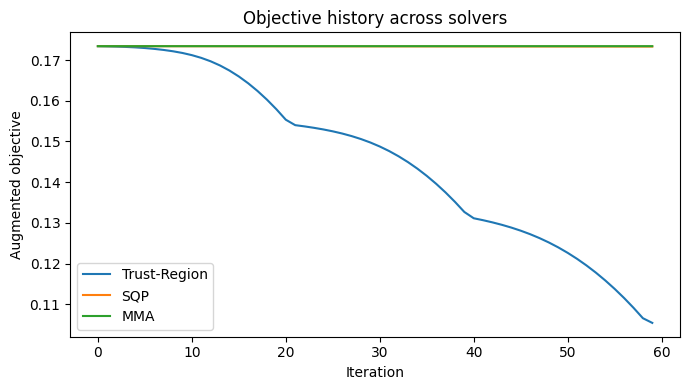

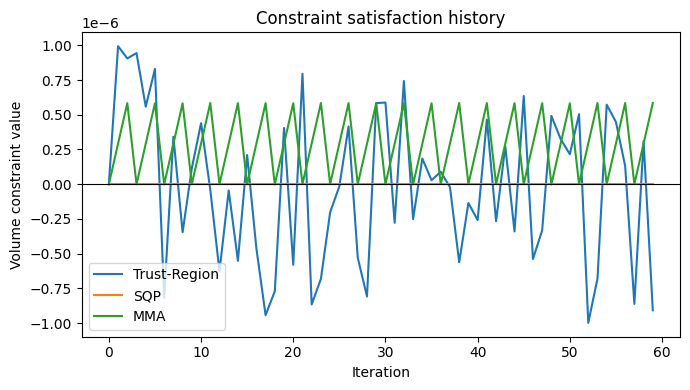

In [35]:
# Convergence comparison plot
plt.figure(figsize=(7, 4))
plt.plot(trust_result["history"]["objective"], label="Trust-Region")
plt.plot(sqp_result["history"]["objective"], label="SQP")
plt.plot(mma_result["history"]["objective"], label="MMA")
plt.xlabel("Iteration")
plt.ylabel("Augmented objective")
plt.title("Objective history across solvers")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(trust_result["history"]["constraint"], label="Trust-Region")
plt.plot(sqp_result["history"]["constraint"], label="SQP")
plt.plot(mma_result["history"]["constraint"], label="MMA")
plt.xlabel("Iteration")
plt.ylabel("Volume constraint value")
plt.axhline(0.0, color="black", linewidth=0.8)
plt.title("Constraint satisfaction history")
plt.legend()
plt.tight_layout()
plt.show()

In [36]:
def animate_density(history: dict, title: str):
    frames = history["densities"]
    if not frames:
        raise ValueError("No frames recorded in history.")
    fig, ax = plt.subplots(figsize=(4, 4))
    im = ax.imshow(frames[0], origin="lower", vmin=0.0, vmax=1.0)
    ax.set_title(f"{title} (iter 0)")
    ax.axis("off")

    def update(frame_idx):
        im.set_data(frames[frame_idx])
        ax.set_title(f"{title} (iter {frame_idx})")
        return (im,)

    anim = animation.FuncAnimation(fig, update, frames=len(frames), interval=120, blit=True)
    plt.close(fig)
    return HTML(anim.to_jshtml())

trust_anim = animate_density(trust_result["history"], "Trust-Region")
sqp_anim = animate_density(sqp_result["history"], "SQP")
mma_anim = animate_density(mma_result["history"], "MMA")

display(trust_anim)
display(sqp_anim)
display(mma_anim)